In [18]:
from google.colab import drive

drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
import os

ruta = "/content/drive/MyDrive/Máster Ciencia de Datos UOC/TFM/desarrollo"
os.chdir(ruta)

In [4]:
import pandas as pd
import model_utils
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit
import joblib as joblib
import random
import seaborn as sns

random.seed(7)

#Porcentaje de los datos de entrenamiento
train_size=0.8
#Porcentaje de los datos de Test
test_size=0.2

#Parrilla de hiper-parámetros para GridSearchCV
parameter_space = {
    'hidden_layer_sizes': [
        (50,), (100,), (150,),
        (100, 50), (50, 50)
    ],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'batch_size': [16, 32, 64],
    'max_iter': [150, 200],
    'alpha': [0.0001, 0.001, 0.01]
}

#Validación cruzada para series temporales
cv = TimeSeriesSplit(n_splits = 10)

In [5]:
df_7d_no_info = pd.read_csv(r'/content/drive/MyDrive/Máster Ciencia de Datos UOC/TFM/desarrollo/qDiario_7d_no_info.csv',parse_dates=['Fecha'], index_col=['Fecha'])

In [6]:
X_train_7d_no_info, X_test_7d_no_info, y_train_7d_no_info, y_test_7d_no_info = model_utils.split_train_test(
    df_7d_no_info,
    train_size_=train_size,
    test_size_=test_size,
    do_scale=True,
    verbose=False
)

In [7]:
mlp = MLPRegressor()

clf_mlp = GridSearchCV(mlp, parameter_space, n_jobs=-1, cv=cv)
clf_mlp.fit(X_train_7d_no_info, y_train_7d_no_info)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=10, test_size=None),
             estimator=MLPRegressor(), n_jobs=-1,
             param_grid={'activation': ['relu', 'tanh'],
                         'alpha': [0.0001, 0.001, 0.01],
                         'batch_size': [16, 32, 64],
                         'hidden_layer_sizes': [(50,), (100,), (150,),
                                                (100, 50), (50, 50)],
                         'max_iter': [150, 200], 'solver': ['adam']})

In [8]:
joblib.dump(clf_mlp, '/content/drive/MyDrive/Máster Ciencia de Datos UOC/TFM/desarrollo/mlp_7d_no_info_normalizado_clf.pkl')

['/content/drive/MyDrive/Máster Ciencia de Datos UOC/TFM/desarrollo/mlp_7d_no_info_normalizado_clf.pkl']

In [9]:
clf_mlp_7d_no_info_normalizado = joblib.load('/content/drive/MyDrive/Máster Ciencia de Datos UOC/TFM/desarrollo/mlp_7d_no_info_normalizado_clf.pkl')
clf_mlp_7d_no_info_normalizado.best_params_

{'activation': 'tanh',
 'alpha': 0.0001,
 'batch_size': 16,
 'hidden_layer_sizes': (150,),
 'max_iter': 200,
 'solver': 'adam'}

In [10]:
predictor_7d_no_info = clf_mlp_7d_no_info_normalizado.best_estimator_

In [11]:
_7d_no_info_RMSE, _7d_no_info_MAE, _7d_no_info_MAPE = model_utils.crear_tabla_errores_cv_train(predictor_7d_no_info,
                                        X_train_7d_no_info, y_train_7d_no_info, cv, '7 días sin contexto')

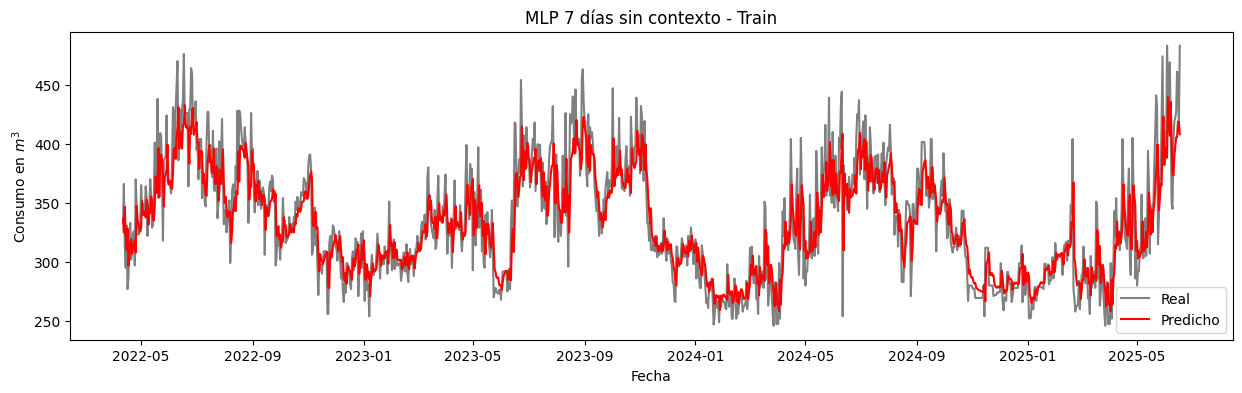

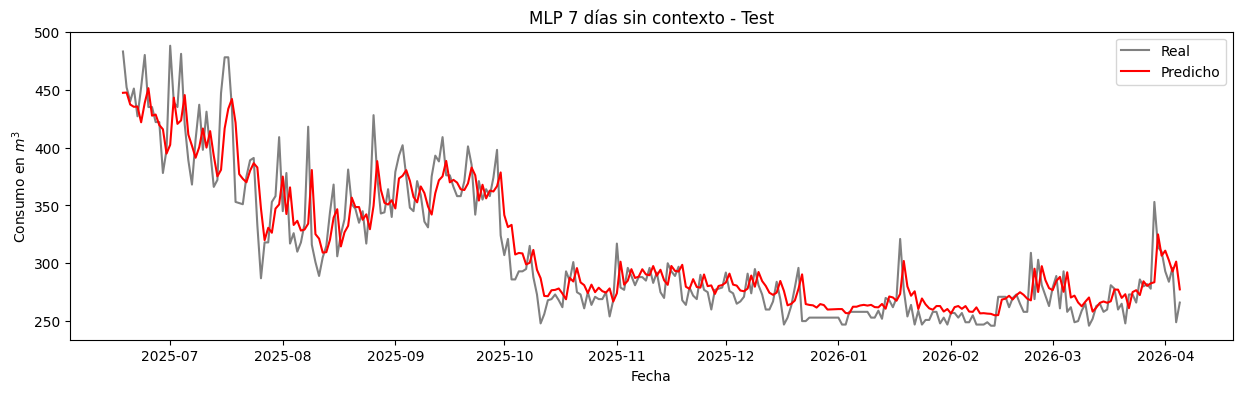

In [12]:
model_utils.grafica_resultado(predictor_7d_no_info, "MLP 7 días sin contexto", df_7d_no_info, train_size, test_size, show_scaled=False)

In [13]:
model_utils.regression_results(y_test_7d_no_info, predictor_7d_no_info.predict(X_test_7d_no_info))

r2: 0.86
MAE: 0.07
MSE: 0.01
RMSE: 0.09
MAPE (%): 26.06
CC: 0.931


In [14]:
df_7d_info = pd.read_csv(r'/content/drive/MyDrive/Máster Ciencia de Datos UOC/TFM/desarrollo/qDiario_7d_info.csv',parse_dates=['Fecha'], index_col=['Fecha'])

In [15]:
X_train_7d_info, X_test_7d_info, y_train_7d_info, y_test_7d_info = model_utils.split_train_test(df_7d_info,
                                                train_size_=train_size,test_size_=test_size,do_scale=True,verbose=False)

In [16]:
mlp = MLPRegressor()

clf_mlp = GridSearchCV(mlp, parameter_space, n_jobs=-1, cv=cv)
clf_mlp.fit(X_train_7d_info, y_train_7d_info)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=10, test_size=None),
             estimator=MLPRegressor(), n_jobs=-1,
             param_grid={'activation': ['relu', 'tanh'],
                         'alpha': [0.0001, 0.001, 0.01],
                         'batch_size': [16, 32, 64],
                         'hidden_layer_sizes': [(50,), (100,), (150,),
                                                (100, 50), (50, 50)],
                         'max_iter': [150, 200], 'solver': ['adam']})

In [20]:
joblib.dump(clf_mlp, 'mlp_7d_info_normalizado_clf.pkl')

['mlp_7d_info_normalizado_clf.pkl']

In [21]:
clf_mlp_7d_info_normalizado = joblib.load('mlp_7d_info_normalizado_clf.pkl')
clf_mlp_7d_info_normalizado.best_params_

{'activation': 'tanh',
 'alpha': 0.0001,
 'batch_size': 64,
 'hidden_layer_sizes': (100, 50),
 'max_iter': 150,
 'solver': 'adam'}

In [22]:
predictor_7d_info = clf_mlp_7d_info_normalizado.best_estimator_

In [23]:
_7d_info_RMSE, _7d_info_MAE, _7d_info_MAPE = model_utils.crear_tabla_errores_cv_train(predictor_7d_info,
                                            X_train_7d_info, y_train_7d_info, cv, '7 días con contexto')

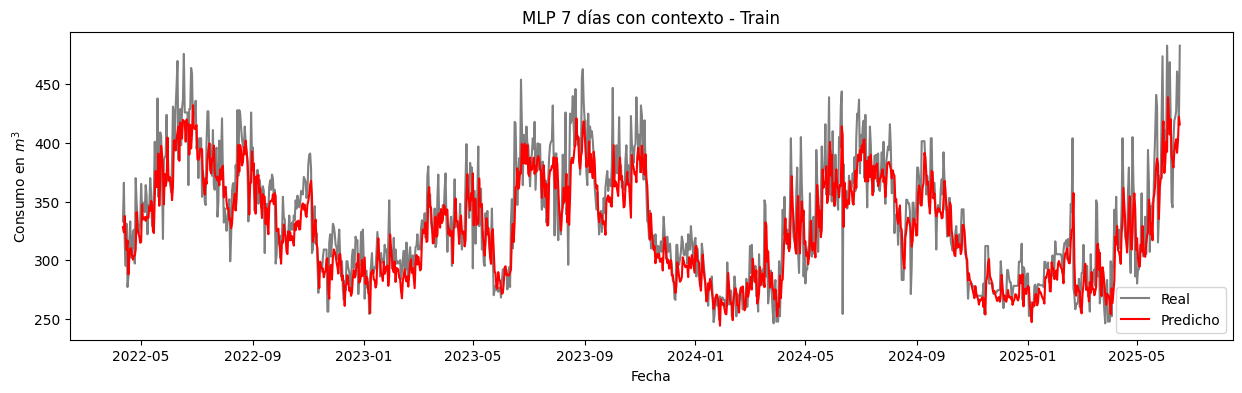

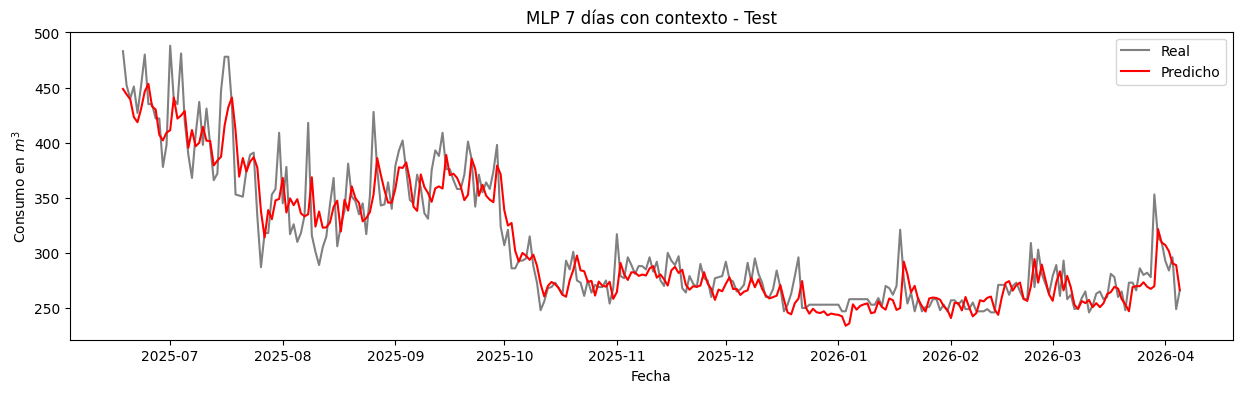

In [24]:
model_utils.grafica_resultado(predictor_7d_info,"MLP 7 días con contexto", df_7d_info,
                            train_size,test_size,show_scaled=False)

In [25]:
model_utils.regression_results(y_test_7d_info, predictor_7d_info.predict(X_test_7d_info))

r2: 0.87
MAE: 0.06
MSE: 0.01
RMSE: 0.09
MAPE (%): 24.62
CC: 0.933


In [26]:
df_14d_no_info = pd.read_csv(r'/content/drive/MyDrive/Máster Ciencia de Datos UOC/TFM/desarrollo/qDiario_14d_no_info.csv',parse_dates=['Fecha'], index_col=['Fecha'])

In [27]:
X_train_14d_no_info, X_test_14d_no_info, y_train_14d_no_info, y_test_14d_no_info = model_utils.split_train_test(df_14d_no_info,
                                                train_size_=train_size,test_size_=test_size,do_scale=True,verbose=False)

In [29]:
mlp = MLPRegressor()

clf_mlp = GridSearchCV(mlp, parameter_space, n_jobs=-1, cv=cv)
clf_mlp.fit(X_train_14d_no_info, y_train_14d_no_info)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=10, test_size=None),
             estimator=MLPRegressor(), n_jobs=-1,
             param_grid={'activation': ['relu', 'tanh'],
                         'alpha': [0.0001, 0.001, 0.01],
                         'batch_size': [16, 32, 64],
                         'hidden_layer_sizes': [(50,), (100,), (150,),
                                                (100, 50), (50, 50)],
                         'max_iter': [150, 200], 'solver': ['adam']})

In [30]:
joblib.dump(clf_mlp, 'mlp_14d_no_info_normalizado_clf.pkl')

['mlp_14d_no_info_normalizado_clf.pkl']

In [31]:
clf_mlp_14d_no_info_normalizado = joblib.load('mlp_14d_no_info_normalizado_clf.pkl')
clf_mlp_14d_no_info_normalizado.best_params_

{'activation': 'tanh',
 'alpha': 0.0001,
 'batch_size': 32,
 'hidden_layer_sizes': (50,),
 'max_iter': 150,
 'solver': 'adam'}

In [32]:
predictor_14d_no_info = clf_mlp_14d_no_info_normalizado.best_estimator_

In [33]:
_14d_no_info_RMSE, _14d_no_info_MAE, _14d_no_info_MAPE = model_utils.crear_tabla_errores_cv_train(predictor_14d_no_info,
                                            X_train_14d_no_info, y_train_14d_no_info, cv,'14 días sin contexto')

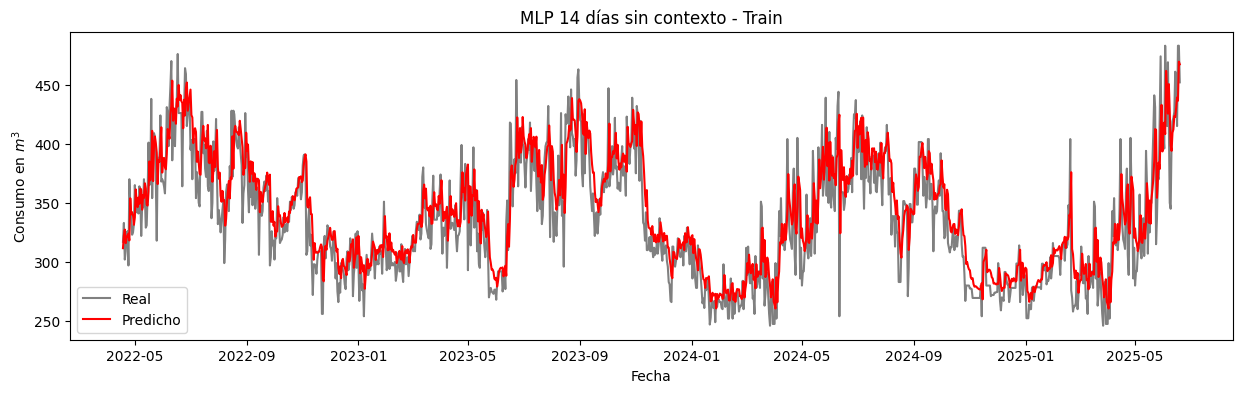

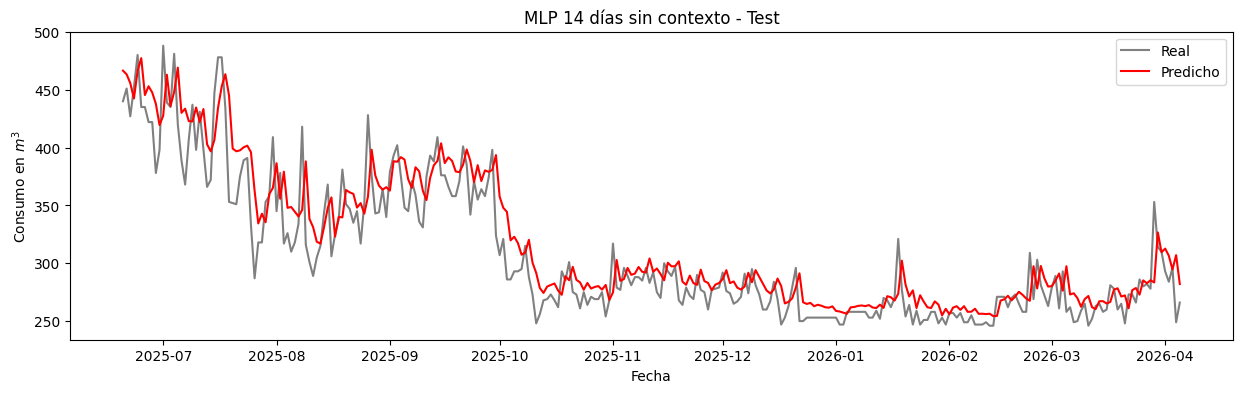

In [34]:
model_utils.grafica_resultado(predictor_14d_no_info,"MLP 14 días sin contexto", df_14d_no_info,
                            train_size,test_size,show_scaled=False)

In [35]:
model_utils.regression_results(y_test_14d_no_info, predictor_14d_no_info.predict(X_test_14d_no_info))

r2: 0.82
MAE: 0.08
MSE: 0.01
RMSE: 0.1
MAPE (%): 30.3
CC: 0.928


In [36]:
df_14d_info = pd.read_csv(r'/content/drive/MyDrive/Máster Ciencia de Datos UOC/TFM/desarrollo/qDiario_14d_info.csv',parse_dates=["Fecha"], index_col=["Fecha"])

In [37]:
X_train_14d_info, X_test_14d_info, y_train_14d_info, y_test_14d_info = model_utils.split_train_test(df_14d_info,
                                                train_size_=train_size,test_size_=test_size,do_scale=True,verbose=False)

In [38]:
mlp = MLPRegressor()

clf_mlp = GridSearchCV(mlp, parameter_space, n_jobs=-1, cv=cv)
clf_mlp.fit(X_train_14d_info, y_train_14d_info)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=10, test_size=None),
             estimator=MLPRegressor(), n_jobs=-1,
             param_grid={'activation': ['relu', 'tanh'],
                         'alpha': [0.0001, 0.001, 0.01],
                         'batch_size': [16, 32, 64],
                         'hidden_layer_sizes': [(50,), (100,), (150,),
                                                (100, 50), (50, 50)],
                         'max_iter': [150, 200], 'solver': ['adam']})

In [39]:
joblib.dump(clf_mlp, 'mlp_14d_info_normalizado_clf.pkl')

['mlp_14d_info_normalizado_clf.pkl']

In [40]:
clf_mlp_14d_info_normalizado = joblib.load('mlp_14d_info_normalizado_clf.pkl')
clf_mlp_14d_info_normalizado.best_params_

{'activation': 'tanh',
 'alpha': 0.01,
 'batch_size': 64,
 'hidden_layer_sizes': (150,),
 'max_iter': 150,
 'solver': 'adam'}

In [41]:
predictor_14d_info = clf_mlp_14d_info_normalizado.best_estimator_


In [42]:
_14d_info_RMSE, _14d_info_MAE, _14d_info_MAPE = model_utils.crear_tabla_errores_cv_train(predictor_14d_info,
                                            X_train_14d_info, y_train_14d_info, cv,'14 días con contexto')

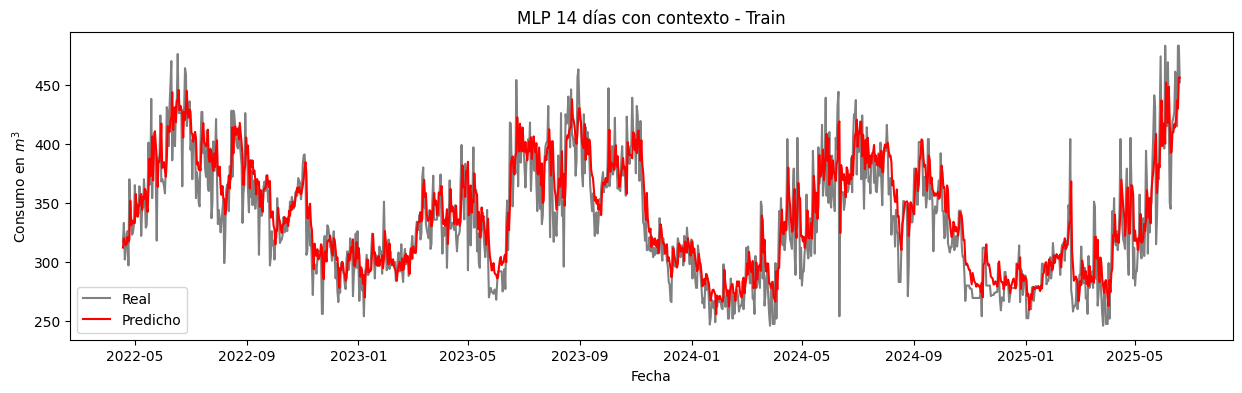

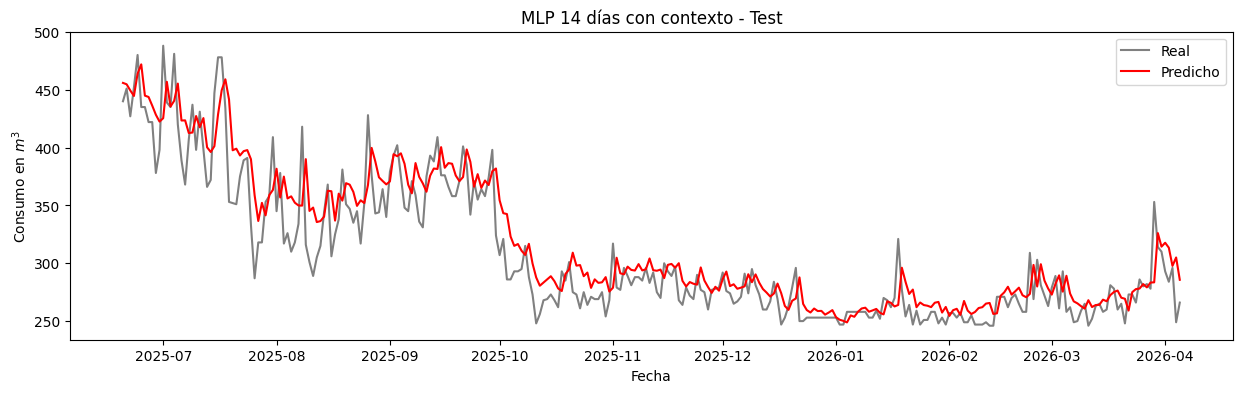

In [43]:
model_utils.grafica_resultado(predictor_14d_info,"MLP 14 días con contexto", df_14d_info,
                            train_size,test_size,show_scaled=False)

In [44]:
model_utils.regression_results(y_test_14d_info, predictor_14d_info.predict(X_test_14d_info))


r2: 0.83
MAE: 0.08
MSE: 0.01
RMSE: 0.1
MAPE (%): 30.07
CC: 0.929


In [45]:
errores_training_rmse = pd.concat([_7d_no_info_RMSE, _7d_info_RMSE, _14d_no_info_RMSE, _14d_info_RMSE], axis=1)
errores_training_rmse

,7 días sin contexto,7 días con contexto,14 días sin contexto,14 días con contexto
0,0.096142,0.091042,0.109000,0.099504
1,0.067363,0.077205,0.070372,0.089043
2,0.092590,0.091339,0.102046,0.096028
3,0.126938,0.122409,0.128620,0.122571
4,0.081775,0.086551,0.085009,0.083262
5,0.087861,0.086299,0.089352,0.097909
6,0.145019,0.135208,0.142906,0.136739
7,0.092952,0.085547,0.083372,0.095879
8,0.072069,0.071123,0.072561,0.076248
9,0.137301,0.136376,0.144528,0.138811


In [46]:
errores_training_rmse.to_csv("/content/drive/MyDrive/Máster Ciencia de Datos UOC/TFM/desarrollo/mlp_rmse_training.csv")


[Text(0.5, 0, 'Dataset utilizado'), Text(0, 0.5, 'RMSE')]

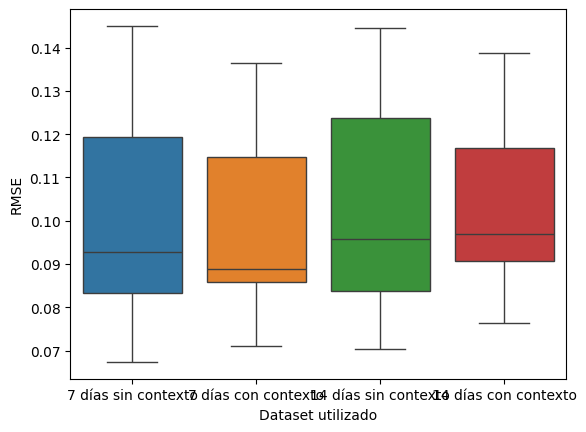

In [47]:
sns.boxplot(data=errores_training_rmse).set(xlabel='Dataset utilizado', ylabel='RMSE')


In [48]:

errores_training_mae = pd.concat([_7d_no_info_MAE, _7d_info_MAE, _14d_no_info_MAE, _14d_info_MAE], axis=1)
errores_training_mae

,7 días sin contexto,7 días con contexto,14 días sin contexto,14 días con contexto
0,0.045148,0.045608,0.061396,0.050044
1,0.038753,0.046590,0.047669,0.064873
2,0.046836,0.059436,0.049079,0.061378
3,0.080032,0.083066,0.074142,0.076452
4,0.044232,0.045402,0.051628,0.050382
5,0.048367,0.045619,0.050641,0.073004
6,0.094055,0.098618,0.087013,0.075856
7,0.052353,0.051314,0.048515,0.060706
8,0.026290,0.032891,0.026041,0.034281
9,0.087534,0.086955,0.086614,0.083659


In [49]:
errores_training_mae.to_csv("/content/drive/MyDrive/Máster Ciencia de Datos UOC/TFM/desarrollo/mlp_mae_training.csv")


[Text(0.5, 0, 'Dataset utilizado'), Text(0, 0.5, 'MAE')]

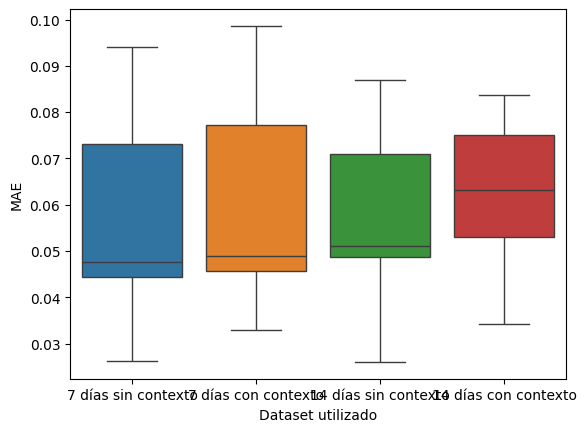

In [50]:
sns.boxplot(data=errores_training_mae).set(xlabel='Dataset utilizado', ylabel='MAE')


In [51]:
errores_training_mape = pd.concat([_7d_no_info_MAPE, _7d_info_MAPE, _14d_no_info_MAPE, _14d_info_MAPE], axis=1)
errores_training_mape

,7 días sin contexto,7 días con contexto,14 días sin contexto,14 días con contexto
0,20.205787,19.633941,23.487949,21.292055
1,22.863282,24.964203,24.638540,32.052245
2,21.871078,23.234219,25.374706,29.820225
3,18.656324,18.781705,18.501697,18.463526
4,17.135674,15.982490,19.031286,18.684371
5,30.419381,29.458167,33.906512,37.246057
6,21.915458,23.726834,24.268976,20.641255
7,27.589475,22.984904,22.713460,30.563228
8,20.313222,23.419540,20.996167,24.167365
9,30.752954,30.031367,31.245135,29.278160


In [52]:
errores_training_mape.to_csv("/content/drive/MyDrive/Máster Ciencia de Datos UOC/TFM/desarrollo/mlp_mape_training.csv")


[Text(0.5, 0, 'Dataset utilizado'), Text(0, 0.5, 'MAPE')]

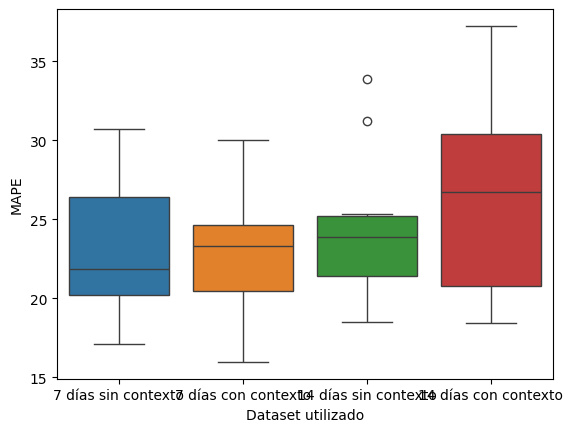

In [53]:
sns.boxplot(data=errores_training_mape).set(xlabel='Dataset utilizado', ylabel='MAPE')
